# 03 — Feature Engineering & Team-Goal Modelling

Goal: build leak-free walk-forward features and select a compact feature set for the team-goal model.

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
import scipy.special as sp
from scipy.stats import poisson
from collections import defaultdict
from pathlib import Path
import math, json, random, datetime

# Brand palette: Green -> Yellow -> Purple -> Red
COLOURS = ['#027B5B', '#F9DC1C', '#54008B', '#D20F2D']

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

DATA_PATH = Path('../Outputs/Cleaning/df_cleaned.csv')
OUT_PATH  = Path('../Outputs/Features')
OUT_PATH.mkdir(parents=True, exist_ok=True)

# --- Notebook config ---
RANDOM_SEED = 2026

TARGET_COL      = "team_goals"
TOTAL_GOALS_COL = "total_goals"

TEST_SEASON = '2024/2025'

DEFAULT_L     = 10
DEFAULT_ALPHA = 0.0

# Derived prior parameters used by the walk-forward builder (Section 6).
L         = DEFAULT_L
ALPHA     = DEFAULT_ALPHA
L_V       = math.ceil(0.5 * L)  # venue-specific lookback
WINDOW_GW = L                   # league-prior lookback, in completed game weeks

# --- Goal bucket scheme (shared by both models) ---
MAX_GOALS_PER_TEAM = 10
TOTAL_GOALS_CAP    = 8
GOAL_BUCKETS       = list(range(TOTAL_GOALS_CAP)) + ['8+']

# Sacred test-set boundary.
LEAGUE_RANK = {'Premier League': 2, 'Championship': 1, 'League One': 0}

# --- Feature selection tolerances ---
VERIFY_TOL             = 0.001   # tolerance used in every feature-selection stage
MAX_PERMUTATION_FEATURES = 8     # 13c: exhaustive subset search only when n <= this
MIN_FEATURES           = 1       # XGB needs at least one feature

# --- Fixed XGBoost baseline params (conservative defaults; not tuned in this notebook) ---
XGB_BASE_PARAMS = {
    "objective":          "count:poisson",
    "n_estimators":       200,
    "learning_rate":      0.05,
    "max_depth":          3,
    "enable_categorical": True,
    "random_state":       RANDOM_SEED,
    "verbosity":          0,
}

In [2]:
# --- Feature-selection config (Section 13) ---
FEATURE_GROUPS = {
    "team_attack":   ["team_avg_gls_f", "team_avg_xg_f", "team_avg_gls_f_v", "team_avg_xg_f_v"],
    "team_defence":  ["team_avg_gls_c", "team_avg_xg_c", "team_avg_gls_c_v", "team_avg_xg_c_v"],
    "opp_attack":    ["opp_avg_gls_f",  "opp_avg_xg_f",  "opp_avg_gls_f_v",  "opp_avg_xg_f_v"],
    "opp_defence":   ["opp_avg_gls_c",  "opp_avg_xg_c",  "opp_avg_gls_c_v",  "opp_avg_xg_c_v"],
    "league_priors": ["league_avg_vgf", "league_avg_vgc"],
    "context":       ["league", "is_home", "is_crowds", "game_week_normalised"],
    "movement":      ["team_promoted_flag", "team_relegated_flag",
                      "opp_promoted_flag",  "opp_relegated_flag"],
}
# All three passes (Pass-1, Pass-2, 13c) use the shared VERIFY_TOL from config.

## 2. Load Raw Data

In [3]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Loaded: 11,239 rows, 12 columns


,league,season,date,game_week,home_team,away_team,home_goals,away_goals,home_xg,away_xg,is_crowds,miss_xg
0,Championship,2018/2019,2018-08-03,1,Reading,Derby_County,1,2,0.9282,0.7231,1,0
1,League One,2018/2019,2018-08-04,1,Burton_Albion,Rochdale,1,2,NaN,NaN,1,1
2,League One,2018/2019,2018-08-04,1,Walsall,Plymouth_Argyle,2,1,NaN,NaN,1,1
3,League One,2018/2019,2018-08-04,1,Southend_United,Doncaster_Rovers,2,3,NaN,NaN,1,1
4,League One,2018/2019,2018-08-04,1,Shrewsbury_Town,Bradford_City,0,1,NaN,NaN,1,1


## 3. Promotion, Relegation & xG Drop

In [4]:
# Build team -> season -> league mapping from full dataset (before any drops)
home_map = df[['home_team', 'season', 'league']].rename(columns={'home_team': 'team'})
away_map = df[['away_team', 'season', 'league']].rename(columns={'away_team': 'team'})
team_season_league = (
    pd.concat([home_map, away_map])
      .drop_duplicates()
      .sort_values(['team', 'season'])
      .reset_index(drop=True)
)

# Identify previous-season league for each team
team_season_league['prev_league'] = team_season_league.groupby('team')['league'].shift(1)
team_season_league['curr_rank']   = team_season_league['league'].map(LEAGUE_RANK)
team_season_league['prev_rank']   = team_season_league['prev_league'].map(LEAGUE_RANK)

# promoted = moved up; relegated = moved down; NaN prev = first season in data = 0
team_season_league['promoted_flag'] = (
    (team_season_league['curr_rank'] > team_season_league['prev_rank']).fillna(False).astype(int)
)
team_season_league['relegated_flag'] = (
    (team_season_league['curr_rank'] < team_season_league['prev_rank']).fillna(False).astype(int)
)

flag_lookup = team_season_league.set_index(['team', 'season'])[['promoted_flag', 'relegated_flag']]

# Merge onto full df for both home and away teams
for side in ['home', 'away']:
    team_col = f'{side}_team'
    merged = df[[team_col, 'season']].merge(
        flag_lookup.rename(columns={
            'promoted_flag': f'{side}_promoted_flag',
            'relegated_flag': f'{side}_relegated_flag'
        }),
        left_on=[team_col, 'season'], right_index=True, how='left'
    )
    df[f'{side}_promoted_flag'] = merged[f'{side}_promoted_flag'].fillna(0).astype(int).values
    df[f'{side}_relegated_flag'] = merged[f'{side}_relegated_flag'].fillna(0).astype(int).values

# Convert to match-level count features
df['num_promoted_teams'] = df['home_promoted_flag'] + df['away_promoted_flag']
df['num_relegated_teams'] = df['home_relegated_flag'] + df['away_relegated_flag']

print(f'Matches with promoted team(s): {(df["num_promoted_teams"] > 0).sum():,}')
print(f'Matches with relegated team(s): {(df["num_relegated_teams"] > 0).sum():,}')
print(f'num_promoted_teams value counts: {dict(df["num_promoted_teams"].value_counts().sort_index())}')

# -- Drop xG-missing rows AFTER movement detection --
xg_missing = df['home_xg'].isna() | df['away_xg'].isna()
df = df[~xg_missing].reset_index(drop=True)
df['total_goals'] = df['home_goals'] + df['away_goals']

print(f'\nAfter dropping missing xG: {len(df):,} rows')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')

Matches with promoted team(s): 1,605
Matches with relegated team(s): 1,731
num_promoted_teams value counts: {0: np.int64(9634), 1: np.int64(1526), 2: np.int64(79)}

After dropping missing xG: 10,687 rows
Date range: 2018-08-03 -> 2026-02-16


## 4. League Seeds

In [5]:
seasons_sorted = sorted(df['season'].unique())

# -- League One seeds: per-TEAM for/against goal & xG rates per season --
# Used during the warm-up of teams entering League One from an untracked competition
# (i.e. with no prior history in the dataset). Each season's seed reads only the
# PREVIOUS season's League One average, so it is always causal.
# A newly-promoted side has no venue/strength signal, so we seed for == against at the
# league's PER-TEAM-PER-MATCH rate: half the previous season's mean total goals (and xG).
l1_seeds = {}
for i, season in enumerate(seasons_sorted):
    if i == 0:
        continue  # first season: no prior season in dataset
    prev = seasons_sorted[i - 1]
    sub  = df[(df['season'] == prev) & (df['league'] == 'League One')]
    if sub.empty:
        continue
    per_team_goals = (sub['home_goals'] + sub['away_goals']).mean() / 2.0
    per_team_xg    = (sub['home_xg']    + sub['away_xg']).mean()    / 2.0
    l1_seeds[season] = {
        'gls_f': per_team_goals, 'gls_c': per_team_goals,
        'xg_f':  per_team_xg,    'xg_c':  per_team_xg,
    }

print('League One seeds (sample):')
for s, v in list(l1_seeds.items())[:3]:
    print(f'  {s}: {v}')

League One seeds (sample):
  2020/2021: {'gls_f': np.float64(1.305), 'gls_c': np.float64(1.305), 'xg_f': np.float64(1.29523457875), 'xg_c': np.float64(1.29523457875)}
  2021/2022: {'gls_f': np.float64(1.3106884057971016), 'gls_c': np.float64(1.3106884057971016), 'xg_f': np.float64(1.2599326893115943), 'xg_c': np.float64(1.2599326893115943)}
  2022/2023: {'gls_f': np.float64(1.348731884057971), 'gls_c': np.float64(1.348731884057971), 'xg_f': np.float64(1.2710979166666667), 'xg_c': np.float64(1.2710979166666667)}


## 5. Helper Functions

In [6]:
PRIOR_KEYS = ['gls_f', 'gls_c', 'xg_f', 'xg_c']


def team_priors(buf, n_home, n_away, seed, window, alpha):
    """
    Backward-looking prior dict for a team: gls_f, gls_c, xg_f, xg_c.

    Warm-up: until the team has BOTH >=1 home and >=1 away match in history, the prior is
    the seed value (or NaN if no seed -> row dropped in Section 7). `n_home`/`n_away` gate
    warm-up only. The SAME gate guards the all-venue and the venue-specific reads — clearing
    it guarantees each venue buffer is non-empty.

    After warm-up: each key is the recency-weighted mean of the buffer's most recent up-to-
    `window` records, weight exp(-alpha * age) with most-recent age 0. alpha=0 -> equal
    weights -> simple mean. `window` is L for the all-venue buffer and L_V for the venue
    buffers, so one function serves both reads.
    """
    in_warmup = (n_home < 1) or (n_away < 1)
    if in_warmup:
        if seed is None:
            return {k: np.nan for k in PRIOR_KEYS}
        return dict(seed)

    recent = buf[-window:]                      # oldest -> newest; n < window handled
    k = len(recent)
    w = np.array([np.exp(-alpha * (k - 1 - i)) for i in range(k)])
    w = w / w.sum()
    return {key: float(np.dot(w, [m[key] for m in recent])) for key in PRIOR_KEYS}


def poisson_nll(y_true, y_pred):
    """Mean Poisson negative log-likelihood (secondary diagnostic)."""
    y_pred = np.clip(y_pred, 1e-8, None)
    return np.mean(y_pred - y_true * np.log(y_pred) + sp.gammaln(y_true + 1))


# -- Checkpoint helpers: append results as we go so a freeze loses at most one cell --------
def load_done(path, key_cols):
    """Return the set of already-completed keys from a results CSV (empty if absent)."""
    if path.exists():
        prev = pd.read_csv(path)
        return set(map(tuple, prev[key_cols].values))
    return set()


def append_row(path, row_dict):
    """Append one result row, writing the header only on first write."""
    pd.DataFrame([row_dict]).to_csv(path, mode='a', header=not path.exists(), index=False)


print('Prior + checkpoint helpers defined.')

def _fold_ll(p):
    ll = p.apply(lambda r: total_goals_logloss(r['pmf'], r['total_goals']), axis=1)
    return ll.groupby(p['val_season'], observed=True).mean()


Prior + checkpoint helpers defined.


In [7]:
# ============================================================================
# Scoreline -> total-goals PMF maths (write once, reuse for Baseline and XGB).
# Every constructor returns a length-len(GOAL_BUCKETS) vector over {0..7, 8+}.
# ============================================================================

def team_pmf(lmbda, max_goals=MAX_GOALS_PER_TEAM):
    """Poisson PMF over 0..max_goals, with the tail mass folded into the last cell."""
    ks = np.arange(max_goals + 1)
    p = poisson.pmf(ks, lmbda).astype(float)
    p[-1] += poisson.sf(max_goals, lmbda)      # sf = 1 - cdf(max_goals): all mass above
    return p                                    # sums to 1.0


def scoreline_matrix(lambda_home, lambda_away, max_goals=MAX_GOALS_PER_TEAM):
    """M[i, j] = P(home scores i, away scores j) under goal independence; sums to 1.0."""
    ph = team_pmf(lambda_home, max_goals)
    pa = team_pmf(lambda_away, max_goals)
    return np.outer(ph, pa)


def total_goals_pmf_from_matrix(M, cap=TOTAL_GOALS_CAP):
    """Anti-diagonal sum of a scoreline matrix -> bucketed total-goals PMF (XGB)."""
    n = M.shape[0]
    totals = np.zeros(2 * (n - 1) + 1)
    for i in range(n):
        for j in range(n):
            totals[i + j] += M[i, j]            # tiny matrix; double loop is fine
    bucketed = np.zeros(cap + 1)                # indices 0..cap; last cell is "cap+"
    bucketed[:cap] = totals[:cap]
    bucketed[cap]  = totals[cap:].sum()
    return bucketed                             # len == cap+1 == len(GOAL_BUCKETS)


def total_goals_pmf_from_lambda(lmbda, cap=TOTAL_GOALS_CAP):
    """Single-Poisson total-goals PMF over 0..cap-1 and a 'cap+' bucket (Baseline)."""
    ks  = np.arange(cap)
    out = np.zeros(cap + 1)
    out[:cap] = poisson.pmf(ks, lmbda)
    out[cap]  = poisson.sf(cap - 1, lmbda)      # mass at >= cap
    return out


def _check_pmf(pmf):
    """Sanity: a PMF must have the bucket length and sum to 1 (guards the log loss)."""
    assert len(pmf) == len(GOAL_BUCKETS), f'PMF length {len(pmf)} != {len(GOAL_BUCKETS)}'
    assert np.isclose(pmf.sum(), 1.0, atol=1e-6), f'PMF sums to {pmf.sum():.6f}, not 1'
    return pmf


def total_goals_logloss(pmf, actual_total, cap=TOTAL_GOALS_CAP, eps=1e-15):
    """-log p(actual). Actual is bucketed into 'cap+' the SAME way as the PMF."""
    idx = min(int(actual_total), cap)
    return -np.log(max(pmf[idx], eps))


def bucket_actual(actual_total, cap=TOTAL_GOALS_CAP):
    """Numeric bucket index of an actual total (>= cap -> the 'cap+' bucket)."""
    return min(int(actual_total), cap)


def rank_of_actual(pmf, actual_total, cap=TOTAL_GOALS_CAP):
    """1-based rank of the actual bucket when buckets are sorted by predicted prob (desc)."""
    idx   = bucket_actual(actual_total, cap)
    order = np.argsort(-pmf, kind='stable')      # most -> least likely bucket
    return int(np.where(order == idx)[0][0]) + 1


# Quick self-test: both PMF constructors agree on shape and normalisation.
_check_pmf(total_goals_pmf_from_lambda(2.6))
_check_pmf(total_goals_pmf_from_matrix(scoreline_matrix(1.4, 1.1)))
print('Scoreline / PMF helpers defined and self-checked.')

Scoreline / PMF helpers defined and self-checked.


## 6. Walk-Forward Feature Generation

One chronological pass; record-before-update; dual buffers feed all-venue and venue-specific priors. Wrapped as `build_features(L, ALPHA)`.

In [8]:
# Pre-compute max game_week per (league, season) for game_week_normalised.
# Schedule property, not a result -> safe to compute once before any loop.
max_gw = df.groupby(['league', 'season'])['game_week'].max().to_dict()
print('max_gw sample:', dict(list(max_gw.items())[:4]))

max_gw sample: {('Championship', '2018/2019'): 46, ('Championship', '2019/2020'): 46, ('Championship', '2020/2021'): 46, ('Championship', '2021/2022'): 46}


In [9]:
def _walk_forward(L, ALPHA):
    """One chronological pass -> wide feature table (NaN priors kept for the drop step).
    Dual team buffers: general (all-venue, window L) + home/away (venue, window L_V)."""
    L_V       = math.ceil(0.5 * L)
    window_gw = L

    team_general_buffer = defaultdict(list)   # all-venue history -> *_avg_*
    team_home_buffer    = defaultdict(list)   # home-only history  -> home *_avg_*_v
    team_away_buffer    = defaultdict(list)   # away-only history  -> away *_avg_*_v
    team_home_count     = defaultdict(int)    # warm-up gate
    team_away_count     = defaultdict(int)
    league_buffer       = defaultdict(list)   # league -> (season, gw, home_goals, away_goals)

    feature_rows = []
    for match_id, row in df.iterrows():       # match_id = df index = chronological key
        league = row['league'];  season = row['season'];  date = row['date']
        ht = row['home_team'];   at = row['away_team']
        hg, ag   = row['home_goals'], row['away_goals']
        hxg, axg = row['home_xg'],    row['away_xg']
        gw       = row['game_week']
        match_tg = hg + ag

        seed = l1_seeds.get(season) if league == 'League One' else None

        # -- League priors: mean home/away goals over the last window_gw game weeks, strictly
        #    earlier than (season, gw). The whole current game week is excluded (no same-round leak).
        curr_key = (season, gw)
        hist = league_buffer[league]
        recent_keys = []
        for (s, g, _h, _a) in reversed(hist):     # date-sorted, so reversed = newest first
            k = (s, g)
            if k != curr_key and k not in recent_keys:
                recent_keys.append(k)
            if len(recent_keys) >= window_gw:
                break
        allowed = set(recent_keys)
        win_hg = [h for (s, g, h, a) in hist if (s, g) in allowed]
        win_ag = [a for (s, g, h, a) in hist if (s, g) in allowed]
        if win_hg:
            league_avg_hg = float(np.mean(win_hg))
            league_avg_ag = float(np.mean(win_ag))
        else:
            league_avg_hg = league_avg_ag = np.nan

        # -- Team priors (READ pre-match). General = all-venue (L); venue = same-venue (L_V).
        h_gen = team_priors(team_general_buffer[ht], team_home_count[ht], team_away_count[ht], seed, L,   ALPHA)
        a_gen = team_priors(team_general_buffer[at], team_home_count[at], team_away_count[at], seed, L,   ALPHA)
        h_ven = team_priors(team_home_buffer[ht],    team_home_count[ht], team_away_count[ht], seed, L_V, ALPHA)
        a_ven = team_priors(team_away_buffer[at],    team_home_count[at], team_away_count[at], seed, L_V, ALPHA)

        gw_norm = gw / max_gw.get((league, season), gw)

        # -- EMIT the wide row BEFORE updating buffers --------------------------
        feature_rows.append({
            'match_id': match_id, 'date': date, 'season': season, 'league': league,
            'game_week': gw, 'home_team': ht, 'away_team': at,
            'total_goals': match_tg, 'home_goals': hg, 'away_goals': ag,
            'n_home_history': len(team_general_buffer[ht]),
            'n_away_history': len(team_general_buffer[at]),
            # all-venue team priors
            'home_avg_gls_f': h_gen['gls_f'], 'home_avg_gls_c': h_gen['gls_c'],
            'home_avg_xg_f':  h_gen['xg_f'],  'home_avg_xg_c':  h_gen['xg_c'],
            'away_avg_gls_f': a_gen['gls_f'], 'away_avg_gls_c': a_gen['gls_c'],
            'away_avg_xg_f':  a_gen['xg_f'],  'away_avg_xg_c':  a_gen['xg_c'],
            # venue-specific team priors (home team's home buffer; away team's away buffer)
            'home_avg_gls_f_v': h_ven['gls_f'], 'home_avg_gls_c_v': h_ven['gls_c'],
            'home_avg_xg_f_v':  h_ven['xg_f'],  'home_avg_xg_c_v':  h_ven['xg_c'],
            'away_avg_gls_f_v': a_ven['gls_f'], 'away_avg_gls_c_v': a_ven['gls_c'],
            'away_avg_xg_f_v':  a_ven['xg_f'],  'away_avg_xg_c_v':  a_ven['xg_c'],
            # league priors (raw home/away means; vgf/vgc routed in the melt, Section 8)
            'league_avg_hg': league_avg_hg, 'league_avg_ag': league_avg_ag,
            # context
            'is_crowds': row['is_crowds'], 'game_week_normalised': gw_norm,
            # per-side movement flags
            'home_promoted_flag':  row['home_promoted_flag'], 'home_relegated_flag': row['home_relegated_flag'],
            'away_promoted_flag':  row['away_promoted_flag'], 'away_relegated_flag': row['away_relegated_flag'],
            'num_promoted_teams':  row['num_promoted_teams'], 'num_relegated_teams': row['num_relegated_teams'],
        })

        # -- UPDATE buffers AFTER recording (record-before-update) --------------
        team_general_buffer[ht].append({'gls_f': hg, 'gls_c': ag, 'xg_f': hxg, 'xg_c': axg})
        team_general_buffer[at].append({'gls_f': ag, 'gls_c': hg, 'xg_f': axg, 'xg_c': hxg})
        team_home_buffer[ht].append({'gls_f': hg, 'gls_c': ag, 'xg_f': hxg, 'xg_c': axg})
        team_away_buffer[at].append({'gls_f': ag, 'gls_c': hg, 'xg_f': axg, 'xg_c': hxg})
        team_home_count[ht] += 1
        team_away_count[at] += 1
        league_buffer[league].append((season, gw, hg, ag))

    return pd.DataFrame(feature_rows)

## 7. Drop Insufficient History Rows

Drop any row missing any prior on the union — keeps Baseline and XGB on identical fixtures; no imputation.

In [10]:
# Union of every prior consumed downstream. All 16 team priors (8 all-venue + 8 venue) plus
# the two league means. league_avg_goals (old Model B) is gone.
PRIOR_COLS = [
    'home_avg_gls_f', 'home_avg_gls_c', 'home_avg_xg_f', 'home_avg_xg_c',
    'away_avg_gls_f', 'away_avg_gls_c', 'away_avg_xg_f', 'away_avg_xg_c',
    'home_avg_gls_f_v', 'home_avg_gls_c_v', 'home_avg_xg_f_v', 'home_avg_xg_c_v',
    'away_avg_gls_f_v', 'away_avg_gls_c_v', 'away_avg_xg_f_v', 'away_avg_xg_c_v',
    'league_avg_hg', 'league_avg_ag',
]


def _drop_insufficient(dfw):
    """Drop rows NaN on any prior (the union); shed the diagnostic history counts."""
    dfw = dfw[~dfw[PRIOR_COLS].isna().any(axis=1)].reset_index(drop=True)
    return dfw.drop(columns=['n_home_history', 'n_away_history'])

## 8. Build Modelling Tables

Melt wide → long: each match becomes a home and an away row with venue-aware league priors and side-routed team/opp priors. `season` stays as a column, not a feature.

In [11]:
def _melt_to_long(dfw):
    """Melt the wide table into a 2-rows-per-match long table (target team_goals).
    Routes venue-aware league priors and venue-specific team/opp priors by side."""
    def _side(is_home):
        me, opp = ('home', 'away') if is_home else ('away', 'home')
        # league venue assignment: a home team scores at the 'hg' rate and concedes at 'ag'.
        vgf = dfw['league_avg_hg'].values if is_home else dfw['league_avg_ag'].values
        vgc = dfw['league_avg_ag'].values if is_home else dfw['league_avg_hg'].values
        return pd.DataFrame({
            'match_id': dfw['match_id'].values, 'date': dfw['date'].values,
            'league': dfw['league'].values, 'season': dfw['season'].values,
            'game_week': dfw['game_week'].values,
            'team': dfw[f'{me}_team'].values, 'opponent': dfw[f'{opp}_team'].values,
            'is_home': is_home, 'target_side': 'home' if is_home else 'away',
            'team_goals': dfw[f'{me}_goals'].values, 'total_goals': dfw['total_goals'].values,
            # league venue-aware priors
            'league_avg_vgf': vgf, 'league_avg_vgc': vgc,
            # team all-venue priors
            'team_avg_gls_f': dfw[f'{me}_avg_gls_f'].values, 'team_avg_gls_c': dfw[f'{me}_avg_gls_c'].values,
            'team_avg_xg_f':  dfw[f'{me}_avg_xg_f'].values,  'team_avg_xg_c':  dfw[f'{me}_avg_xg_c'].values,
            # team venue-specific priors
            'team_avg_gls_f_v': dfw[f'{me}_avg_gls_f_v'].values, 'team_avg_gls_c_v': dfw[f'{me}_avg_gls_c_v'].values,
            'team_avg_xg_f_v':  dfw[f'{me}_avg_xg_f_v'].values,  'team_avg_xg_c_v':  dfw[f'{me}_avg_xg_c_v'].values,
            # opponent all-venue priors
            'opp_avg_gls_f': dfw[f'{opp}_avg_gls_f'].values, 'opp_avg_gls_c': dfw[f'{opp}_avg_gls_c'].values,
            'opp_avg_xg_f':  dfw[f'{opp}_avg_xg_f'].values,  'opp_avg_xg_c':  dfw[f'{opp}_avg_xg_c'].values,
            # opponent venue-specific priors (opponent is always at the complementary venue)
            'opp_avg_gls_f_v': dfw[f'{opp}_avg_gls_f_v'].values, 'opp_avg_gls_c_v': dfw[f'{opp}_avg_gls_c_v'].values,
            'opp_avg_xg_f_v':  dfw[f'{opp}_avg_xg_f_v'].values,  'opp_avg_xg_c_v':  dfw[f'{opp}_avg_xg_c_v'].values,
            # movement flags, per side
            'team_promoted_flag': dfw[f'{me}_promoted_flag'].values, 'team_relegated_flag': dfw[f'{me}_relegated_flag'].values,
            'opp_promoted_flag':  dfw[f'{opp}_promoted_flag'].values, 'opp_relegated_flag':  dfw[f'{opp}_relegated_flag'].values,
            # context
            'is_crowds': dfw['is_crowds'].values, 'game_week_normalised': dfw['game_week_normalised'].values,
        })
    dl = pd.concat([_side(1), _side(0)], ignore_index=True)
    return dl.sort_values(['date', 'match_id', 'is_home'],
                          ascending=[True, True, False]).reset_index(drop=True)


def build_features(L, ALPHA):
    """Full pipeline: walk-forward -> drop insufficient history -> wide + long tables.
    season and league are set as ordered/plain categoricals on both frames."""
    dfw = _drop_insufficient(_walk_forward(L, ALPHA))
    season_dtype = pd.CategoricalDtype(categories=sorted(dfw['season'].unique()), ordered=True)
    dfw['season'] = dfw['season'].astype(season_dtype)
    dfw['league'] = dfw['league'].astype('category')
    dl = _melt_to_long(dfw)
    dl['season'] = dl['season'].astype(season_dtype)
    dl['league'] = dl['league'].astype('category')
    return dfw, dl

In [12]:
# Build the canonical tables at the fixed defaults (DEFAULT_L, DEFAULT_ALPHA).
df_wide, df_long = build_features(L, ALPHA)

df_wide.to_csv(OUT_PATH / 'df_features_wide.csv', index=False)
df_long.to_csv(OUT_PATH / 'df_features_long.csv', index=False)

# Integrity: same fixtures, exactly 2 rows/match, team_goals sums back to total_goals.
assert set(df_long['match_id']) == set(df_wide['match_id']), 'wide/long fixtures diverge!'
assert (df_long.groupby('match_id').size() == 2).all(), 'a fixture is not exactly 2 rows!'
recon = df_long.groupby('match_id')['team_goals'].sum()
assert recon.equals(df_wide.set_index('match_id')['total_goals'].loc[recon.index]), 'team_goals != total_goals!'

print(f'Wide: {df_wide.shape[0]:,} matches x {df_wide.shape[1]} cols')
print(f'Long: {df_long.shape[0]:,} rows x {df_long.shape[1]} cols  (= 2 x {df_wide.shape[0]:,})')
print(f'Saved -> {OUT_PATH / "df_features_wide.csv"}  |  {OUT_PATH / "df_features_long.csv"}')

Wide: 10,610 matches x 36 cols
Long: 21,220 rows x 35 cols  (= 2 x 10,610)
Saved -> ../Outputs/Features/df_features_wide.csv  |  ../Outputs/Features/df_features_long.csv


In [13]:
# Leakage guard: priors must use only strictly-earlier matches (record-before-update).
# Re-derivation assumes ALPHA == 0 (simple mean); the canonical build runs at ALPHA = 0.
sample = df_wide[df_wide['season'].astype(str) == '2022/2023'].iloc[10]
mid, ht = sample['match_id'], sample['home_team']

gen_rows = df[(df.index < mid) & ((df['home_team'] == ht) | (df['away_team'] == ht))].tail(L)
gen_gls_f = [(r['home_goals'] if r['home_team'] == ht else r['away_goals']) for _, r in gen_rows.iterrows()]
ven_rows = df[(df.index < mid) & (df['home_team'] == ht)].tail(L_V)        # home team's HOME matches only
ven_gls_f = ven_rows['home_goals'].tolist()

man_gen = np.mean(gen_gls_f) if gen_gls_f else np.nan
man_ven = np.mean(ven_gls_f) if ven_gls_f else np.nan
print(f'home_avg_gls_f   stored {sample["home_avg_gls_f"]:.4f}  vs re-derived {man_gen:.4f}')
print(f'home_avg_gls_f_v stored {sample["home_avg_gls_f_v"]:.4f}  vs re-derived {man_ven:.4f}')
assert np.isclose(sample['home_avg_gls_f'],   man_gen, atol=1e-6), 'all-venue prior leaked the current match!'
assert np.isclose(sample['home_avg_gls_f_v'], man_ven, atol=1e-6), 'venue prior leaked the current match!'
print('OK: both priors use only strictly-earlier (same-venue) matches.')

print('\nLong — first 4 rows (home/away halves of the first matches):')
display(df_long.head(4))

home_avg_gls_f   stored 1.3000  vs re-derived 1.3000
home_avg_gls_f_v stored 0.8000  vs re-derived 0.8000
OK: both priors use only strictly-earlier (same-venue) matches.

Long — first 4 rows (home/away halves of the first matches):


,match_id,date,league,season,game_week,team,opponent,is_home,target_side,team_goals,total_goals,league_avg_vgf,league_avg_vgc,team_avg_gls_f,team_avg_gls_c,team_avg_xg_f,team_avg_xg_c,team_avg_gls_f_v,team_avg_gls_c_v,team_avg_xg_f_v,team_avg_xg_c_v,opp_avg_gls_f,opp_avg_gls_c,opp_avg_xg_f,opp_avg_xg_c,opp_avg_gls_f_v,opp_avg_gls_c_v,opp_avg_xg_f_v,opp_avg_xg_c_v,team_promoted_flag,team_relegated_flag,opp_promoted_flag,opp_relegated_flag,is_crowds,game_week_normalised
0,36,2018-08-17,Championship,2018/2019,3,Birmingham_City,Swansea_City,1,home,0,0,1.653846,1.423077,1.0,1.500000,0.890030,1.691805,2.0,2.0,1.30576,1.79621,1.5,0.500000,1.297300,0.646735,2.0,1.0,0.95200,0.63750,0,0,0,0,1,0.065217
1,36,2018-08-17,Championship,2018/2019,3,Swansea_City,Birmingham_City,0,away,0,0,1.423077,1.653846,1.5,0.500000,1.297300,0.646735,2.0,1.0,0.95200,0.63750,1.0,1.500000,0.890030,1.691805,2.0,2.0,1.30576,1.79621,0,0,0,0,1,0.065217
2,37,2018-08-18,Championship,2018/2019,3,Bristol_City,Middlesbrough,1,home,0,2,1.653846,1.423077,1.5,1.500000,0.805820,0.661850,1.0,1.0,0.35720,0.72570,2.0,0.666667,1.453507,1.274133,2.0,2.0,1.85202,2.24440,0,0,0,0,1,0.065217
3,37,2018-08-18,Championship,2018/2019,3,Middlesbrough,Bristol_City,0,away,2,2,1.423077,1.653846,2.0,0.666667,1.453507,1.274133,2.0,2.0,1.85202,2.24440,1.5,1.500000,0.805820,0.661850,1.0,1.0,0.35720,0.72570,0,0,0,0,1,0.065217


## 9. Train / Test Split

In [14]:
df_dev_wide  = df_wide[df_wide['season'] < TEST_SEASON].copy()
df_test_wide = df_wide[df_wide['season'] >= TEST_SEASON].copy()
df_dev_long  = df_long[df_long['season'] < TEST_SEASON].copy()
df_test_long = df_long[df_long['season'] >= TEST_SEASON].copy()

# Validation seasons: all dev seasons except the first (needs >= 1 train season).
dev_seasons = sorted(df_dev_wide['season'].unique())
val_seasons = dev_seasons[1:]

print(f'Dev : {len(df_dev_wide):,} matches  seasons={[str(s) for s in dev_seasons]}')
print(f'Test: {len(df_test_wide):,} matches  seasons={sorted(str(s) for s in df_test_wide["season"].unique())}')
print(f'Validation seasons: {[str(s) for s in val_seasons]}')

# Guard against the "== collapse" trap: test must contain BOTH 2024/25 and 2025/26.
test_seasons = set(map(str, df_test_wide['season'].unique()))
assert '2024/2025' in test_seasons and '2025/2026' in test_seasons, \
    'Test set must include BOTH 2024/2025 and 2025/2026 (>= cutoff, not == single season).'
print('Test split is a cutoff (>=) and includes 2025/26. Test set is now frozen.')

Dev : 8,122 matches  seasons=['2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024']
Test: 2,488 matches  seasons=['2024/2025', '2025/2026']
Validation seasons: ['2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024']
Test split is a cutoff (>=) and includes 2025/26. Test set is now frozen.


## 10. Baseline — League Mean Total Goals

Per-league mean `total_goals` → single-Poisson PMF.

In [15]:
def run_baseline(dev_wide, val_seasons):
    """Per-league mean total goals from training -> single-Poisson total-goals PMF."""
    recs = []
    for vs in val_seasons:
        train = dev_wide[dev_wide['season'] < vs]
        val   = dev_wide[dev_wide['season'] == vs]
        if train.empty or val.empty:
            continue
        lambda_map = train.groupby('league', observed=True)['total_goals'].mean().to_dict()
        val = val[val['league'].isin(lambda_map.keys())]   # exclude leagues absent from train
        for _, r in val.iterrows():
            lam = float(lambda_map[r['league']])
            pmf = _check_pmf(total_goals_pmf_from_lambda(lam))
            recs.append({
                'model': 'Baseline', 'val_season': vs, 'match_id': r['match_id'],
                'league': r['league'], 'total_goals': int(r['total_goals']),
                'expected': lam, 'pmf': pmf,
            })
    return pd.DataFrame(recs)


preds_baseline = run_baseline(df_dev_wide, val_seasons)
print(f'Baseline predictions: {len(preds_baseline):,} matches across {preds_baseline["val_season"].nunique()} folds')

Baseline predictions: 6,862 matches across 5 folds


## 11. XGB — Team-Goal Scoreline Model

Per-team `count:poisson` λ → re-pair by `match_id` → scoreline matrix → bucketed total-goals PMF.

In [16]:
TEAM_GOALS_FEATS = [
    'league',
    # league venue-aware priors (assigned by THIS team's venue)
    'league_avg_vgf', 'league_avg_vgc',
    # team all-venue priors
    'team_avg_gls_f', 'team_avg_gls_c', 'team_avg_xg_f', 'team_avg_xg_c',
    # team venue-specific priors
    'team_avg_gls_f_v', 'team_avg_gls_c_v', 'team_avg_xg_f_v', 'team_avg_xg_c_v',
    # opponent all-venue priors
    'opp_avg_gls_f', 'opp_avg_gls_c', 'opp_avg_xg_f', 'opp_avg_xg_c',
    # opponent venue-specific priors
    'opp_avg_gls_f_v', 'opp_avg_gls_c_v', 'opp_avg_xg_f_v', 'opp_avg_xg_c_v',
    # context
    'is_home', 'is_crowds', 'game_week_normalised',
    # movement flags
    'team_promoted_flag', 'team_relegated_flag',
    'opp_promoted_flag',  'opp_relegated_flag',
]
TEAM_GOALS_TARGET = 'team_goals'


def run_xgb(dev_long, val_seasons, feats=TEAM_GOALS_FEATS, params=None, label='XGB'):
    """XGBoost per-team lambda -> re-pair by match_id -> scoreline matrix -> total-goals PMF.
    Parameterised on feats + params so the tuning and ablation stages reuse it unchanged."""
    if params is None:
        params = XGB_BASE_PARAMS
    recs = []
    for vs in val_seasons:
        train = dev_long[dev_long['season'] < vs]
        val   = dev_long[dev_long['season'] == vs]
        if train.empty or val.empty:
            continue
        valid_leagues = set(train['league'].unique())
        val = val[val['league'].isin(valid_leagues)].copy()   # both rows share league -> match-level
        if val.empty:
            continue
        model = xgb.XGBRegressor(**params)
        model.fit(train[feats], train[TEAM_GOALS_TARGET])
        val['lam'] = np.clip(model.predict(val[feats]), 1e-8, None)

        for mid, grp in val.groupby('match_id'):
            home = grp[grp['is_home'] == 1]
            away = grp[grp['is_home'] == 0]
            if len(home) != 1 or len(away) != 1:
                continue   # never score a half-fixture
            lh = float(home['lam'].iloc[0])
            la = float(away['lam'].iloc[0])
            pmf = _check_pmf(total_goals_pmf_from_matrix(scoreline_matrix(lh, la)))
            recs.append({
                'model': label, 'val_season': vs, 'match_id': mid,
                'league': home['league'].iloc[0],
                'total_goals': int(home['total_goals'].iloc[0]),
                'expected': lh + la, 'pmf': pmf, 'lambda_home': lh, 'lambda_away': la,
            })
    return pd.DataFrame(recs)

## 12. Tuning Handoff

Saves the fixed feature-building and base-XGB settings as a starting point for 04_Tuning so it has a defined place to begin. No tuning happens here.

In [17]:
def cv_logloss(dev_long, val_seasons, feats=TEAM_GOALS_FEATS, params=None):
    """Expanding-window temporal CV. Reuses run_xgb + total_goals_logloss (the existing scorer):
    mean bucketed total-goals log loss per fold, then mean across folds."""
    preds = run_xgb(dev_long, val_seasons, feats=feats, params=params)
    if preds.empty:
        return np.nan, np.nan, {}
    ll = preds.apply(lambda r: total_goals_logloss(r['pmf'], r['total_goals']), axis=1)
    fold = ll.groupby(preds['val_season'], observed=True).mean()
    return float(fold.mean()), float(fold.std()), {str(k): float(v) for k, v in fold.items()}

In [18]:
tuning_start = {
    "starting_L":          DEFAULT_L,
    "starting_ALPHA":      DEFAULT_ALPHA,
    "starting_xgb_params": XGB_BASE_PARAMS,
    "note": "Fixed starting config from 03_Features; tuning is performed in 04_Tuning.",
}
with open(OUT_PATH / 'tuning_start.json', 'w') as f:
    json.dump(tuning_start, f, indent=2)
print(f'tuning_start.json written: starting_L={DEFAULT_L}, starting_ALPHA={DEFAULT_ALPHA}')

tuning_start.json written: starting_L=10, starting_ALPHA=0.0


## 13. Feature Selection

Three-stage compression + combination-removal verification, all driven by walk-forward CV log loss. SHAP is diagnostic only.

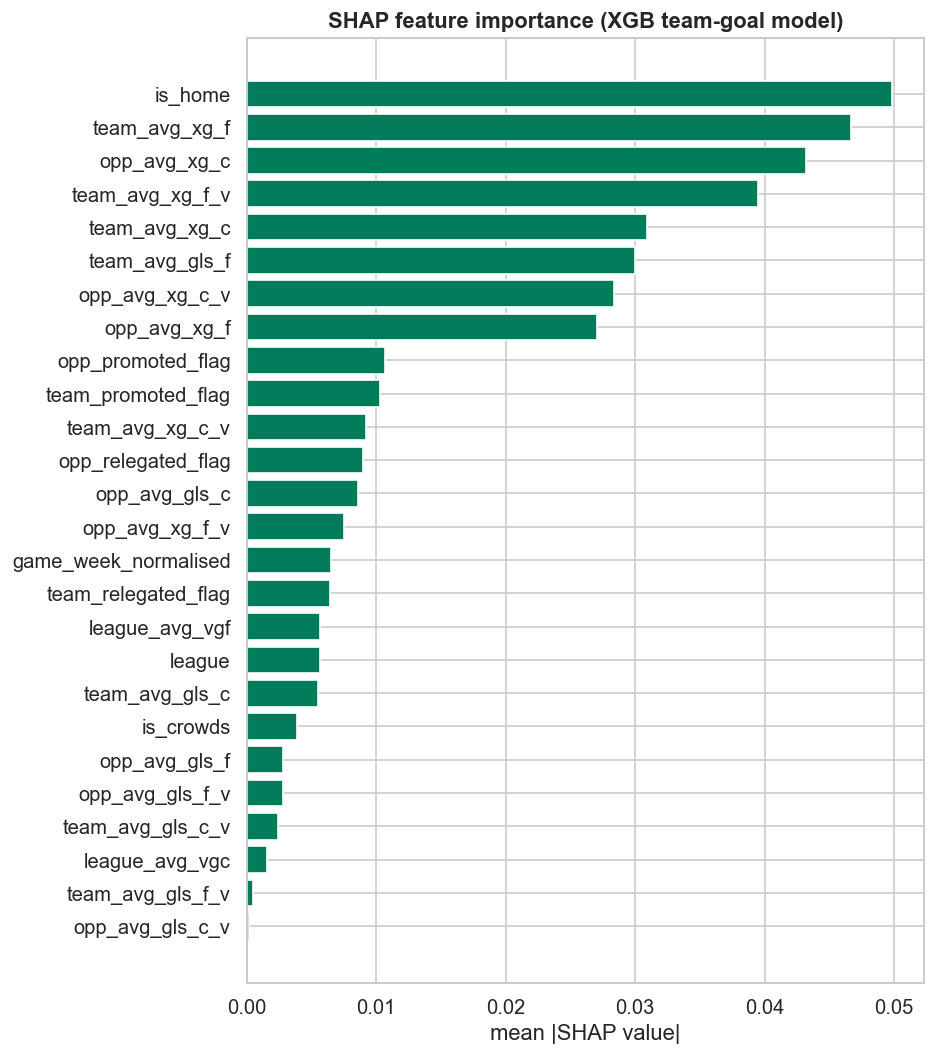

SHAP mean|value| ranking (high -> low):
is_home                 0.0499
team_avg_xg_f           0.0466
opp_avg_xg_c            0.0432
team_avg_xg_f_v         0.0395
team_avg_xg_c           0.0310
team_avg_gls_f          0.0300
opp_avg_xg_c_v          0.0283
opp_avg_xg_f            0.0271
opp_promoted_flag       0.0107
team_promoted_flag      0.0103
team_avg_xg_c_v         0.0092
opp_relegated_flag      0.0090
opp_avg_gls_c           0.0086
opp_avg_xg_f_v          0.0075
game_week_normalised    0.0065
team_relegated_flag     0.0064
league_avg_vgf          0.0057
league                  0.0057
team_avg_gls_c          0.0055
is_crowds               0.0039
opp_avg_gls_f           0.0028
opp_avg_gls_f_v         0.0028
team_avg_gls_c_v        0.0024
league_avg_vgc          0.0016
team_avg_gls_f_v        0.0005
opp_avg_gls_c_v         0.0002


In [19]:
# 13a. SHAP importance. We use XGBoost's native TreeSHAP via pred_contribs (DMatrix with
# enable_categorical) — identical to shap.TreeExplainer but categorical-safe for 'league'.
shap_model = xgb.XGBRegressor(**XGB_BASE_PARAMS)
shap_model.fit(df_dev_long[TEAM_GOALS_FEATS], df_dev_long[TEAM_GOALS_TARGET])

dm = xgb.DMatrix(df_dev_long[TEAM_GOALS_FEATS], enable_categorical=True)
contribs = shap_model.get_booster().predict(dm, pred_contribs=True)   # (n, n_feats + 1); last col = bias
shap_imp = pd.Series(np.abs(contribs[:, :-1]).mean(axis=0), index=TEAM_GOALS_FEATS).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(shap_imp.index, shap_imp.values, color=COLOURS[0], edgecolor='white')
ax.set_xlabel('mean |SHAP value|')
ax.set_title('SHAP feature importance (XGB team-goal model)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'shap_summary.png', bbox_inches='tight')
plt.show()

print('SHAP mean|value| ranking (high -> low):')
print(shap_imp.sort_values(ascending=False).round(4).to_string())
shap_imp.sort_values(ascending=False).to_csv(OUT_PATH / 'shap_importance.csv')

In [20]:
# 13b. Staged compression of the feature set: Pass-1 group compression -> Pass-2 group compression
# (with the rest of the model already reduced). Driven by walk-forward CV log loss; SHAP is a
# tie-breaker only. Every subset is checkpointed (append_row) and resumable (load_done).
#
# Selection philosophy: we pick the smallest feature subset within a fixed tolerance of the best
# validation log loss, rather than blindly choosing the lowest-loss model. This favours simpler
# feature sets where differences are within CV noise.
from itertools import combinations


def subsets(items):
    """All subsets of `items`, smallest first (includes the empty subset and the full set)."""
    items = list(items)
    for r in range(len(items) + 1):
        yield from combinations(items, r)


def _subset_key(features):
    return "|".join(sorted(features))


def _pick_smallest_near_best(rows, tol, size_key='features'):
    """rows: list of {<size_key>: list, 'logloss_mean': float, 'logloss_std': float}.
    Near-best rule + 4 tie-breakers, IN ORDER: fewest features -> lowest logloss ->
    lowest logloss_std -> higher summed SHAP importance (shap_imp)."""
    best = min(r['logloss_mean'] for r in rows)
    eligible = [r for r in rows if r['logloss_mean'] <= best + tol]
    eligible.sort(key=lambda r: (len(r[size_key]), r['logloss_mean'], r['logloss_std'],
                                 -float(shap_imp.reindex(r[size_key]).fillna(0.0).sum())))
    return list(eligible[0][size_key]), best


def _pick_smallest_near_anchor(rows, anchor_ll, tol, size_key='features'):
    """Pick the smallest subset within (anchor_ll + tol). If none qualifies, fall back to the
    rows tied for the lowest logloss. Same 4 tie-breakers as _pick_smallest_near_best."""
    eligible = [r for r in rows if r['logloss_mean'] <= anchor_ll + tol]
    if not eligible:
        best = min(r['logloss_mean'] for r in rows)
        eligible = [r for r in rows if r['logloss_mean'] == best]
    eligible.sort(key=lambda r: (len(r[size_key]), r['logloss_mean'], r['logloss_std'],
                                 -float(shap_imp.reindex(r[size_key]).fillna(0.0).sum())))
    return list(eligible[0][size_key])


def _back_fill_winners(path, group_winners, tol, by_group=True):
    """Re-read a per-subset CSV, back-fill delta_vs_group_best and selected_group_winner."""
    gdf = pd.read_csv(path)
    gdf['feats_list'] = gdf['subset_features'].fillna('').apply(lambda s: s.split('|') if s else [])
    for g, win in group_winners.items():
        sub = gdf[gdf['group'] == g] if by_group else gdf
        best = sub['logloss_mean'].min()
        mask = (gdf['group'] == g) if by_group else slice(None)
        gdf.loc[mask, 'delta_vs_group_best'] = gdf.loc[mask, 'logloss_mean'] - best
        gdf.loc[(mask if isinstance(mask, slice) else mask) &
                (gdf['subset_features'].fillna('') == _subset_key(win)),
                'selected_group_winner'] = True
    gdf.drop(columns=['feats_list']).to_csv(path, index=False)


# Coverage assert (every TEAM_GOALS_FEATS feature is in exactly one group; no dupes).
grouped = [f for group in FEATURE_GROUPS.values() for f in group]
missing = set(TEAM_GOALS_FEATS) - set(grouped)
extra   = set(grouped) - set(TEAM_GOALS_FEATS)
dupes   = pd.Series(grouped).value_counts(); dupes = dupes[dupes > 1]
assert not missing, f'Features missing from FEATURE_GROUPS: {missing}'
assert not extra,   f'Unknown features in FEATURE_GROUPS: {extra}'
assert dupes.empty, f'Features appear in multiple groups: {dupes.to_dict()}'

# Reference: full-feature CV log loss + the baseline number for context.
full_ll, full_std, _ = cv_logloss(df_dev_long, val_seasons, feats=TEAM_GOALS_FEATS, params=XGB_BASE_PARAMS)
baseline_ll = _fold_ll(run_baseline(df_dev_wide, val_seasons)).mean()
print(f'Full-feature CV logloss: {full_ll:.4f} +/- {full_std:.4f}')
print(f'Baseline      CV logloss: {baseline_ll:.4f}\n')


def _run_group_pass(stage_name, outside_lookup, members_lookup, tol, path, *, anchor_ll=None):
    """Run one group-compression pass; return group_winners dict.
    outside_lookup(g) -> list of features that stay fixed at full membership while group g is searched.
    members_lookup(g) -> list of candidate features inside group g (search varies over all subsets)."""
    done = load_done(path, ['group', 'subset_features'])
    for g in FEATURE_GROUPS:
        outside = outside_lookup(g)
        members = members_lookup(g)
        for sub in subsets(members):
            key = _subset_key(sub)
            if (g, key) in done:
                continue
            feats = outside + list(sub)
            if not feats:                # XGB needs >= 1 feature
                continue
            ll, sd, _ = cv_logloss(df_dev_long, val_seasons, feats=feats, params=XGB_BASE_PARAMS)
            append_row(path, {
                'group': g, 'subset_size': len(sub), 'subset_features': key,
                'n_features_total': len(feats), 'logloss_mean': ll, 'logloss_std': sd,
                'delta_vs_full': ll - full_ll, 'delta_vs_group_best': np.nan,
                'selected_group_winner': False,
            })
        print(f'[{stage_name}] {g:<14} {2 ** len(members):>2} subsets scored')
    # Winners (re-read so resume works).
    gdf = pd.read_csv(path)
    gdf['feats_list'] = gdf['subset_features'].fillna('').apply(lambda s: s.split('|') if s else [])
    winners = {}
    for g in FEATURE_GROUPS:
        sub = gdf[gdf['group'] == g]
        rows = [{'features': r.feats_list, 'logloss_mean': r.logloss_mean, 'logloss_std': r.logloss_std}
                for r in sub.itertuples()]
        if not rows:
            winners[g] = list(members_lookup(g))     # nothing scored (e.g. all skipped) -> keep all
            continue
        if anchor_ll is None:                                 # Pass 1 — within-group anchor
            win, _ = _pick_smallest_near_best(rows, tol)
        else:                                                  # Pass 2 — full-model anchor
            win = _pick_smallest_near_anchor(rows, anchor_ll, tol)
        winners[g] = win
    _back_fill_winners(path, winners, tol, by_group=True)
    return winners


# ---- Stage 1: first-pass group compression. All OTHER groups held at full membership. ----
pass1_path = OUT_PATH / 'feature_group_search_pass1_results.csv'
group_winners_pass1 = _run_group_pass(
    'pass1', lambda g: [f for og, fs in FEATURE_GROUPS.items() if og != g for f in fs],
    lambda g: FEATURE_GROUPS[g], VERIFY_TOL, pass1_path,
)
candidate_features_pass1 = [f for g in FEATURE_GROUPS for f in group_winners_pass1[g]]
print('\nPass-1 winners:')
for g, w in group_winners_pass1.items():
    print(f'  {g:<14} -> {w if w else "[] (dropped)"}')
cand1_ll, _, _ = cv_logloss(df_dev_long, val_seasons,
                            feats=candidate_features_pass1 or list(TEAM_GOALS_FEATS[:1]),
                            params=XGB_BASE_PARAMS)

# ---- Stage 2: second pass. Outside world = Pass-1 winners; search varies over each group's Pass-1 winner. ----
pass2_path = OUT_PATH / 'feature_group_search_pass2_results.csv'
group_winners_pass2 = _run_group_pass(
    'pass2', lambda g: [f for og in FEATURE_GROUPS if og != g for f in group_winners_pass1[og]],
    lambda g: group_winners_pass1[g], VERIFY_TOL, pass2_path,
    anchor_ll=full_ll,                              # Pass 2 anchors to the FULL model, not its own best
)
candidate_features_pass2 = [f for g in FEATURE_GROUPS for f in group_winners_pass2[g]]
print('\nPass-2 winners:')
for g, w in group_winners_pass2.items():
    print(f'  {g:<14} -> {w if w else "[] (dropped)"}')
# Provisional set: the Pass-2 candidate. 13c will verify it can be compressed further.
provisional = list(candidate_features_pass2)
provisional_ll, provisional_std, _ = cv_logloss(
    df_dev_long, val_seasons,
    feats=provisional or list(TEAM_GOALS_FEATS[:1]),     # XGB needs >=1 feature
    params=XGB_BASE_PARAMS,
)
if provisional_ll > full_ll + VERIFY_TOL:
    print(f'WARNING: provisional logloss {provisional_ll:.4f} is more than '
          f'VERIFY_TOL={VERIFY_TOL:.4f} above full model {full_ll:.4f}.')

# ---- Report block ----
print('\n=== Selection summary (mean fold CV log loss) ===')
print(f'  Full model       ({len(TEAM_GOALS_FEATS):2d}f): {full_ll:.4f}')
print(f'  Pass-1 candidate ({len(candidate_features_pass1):2d}f): {cand1_ll:.4f}')
print(f'  Provisional      ({len(provisional):2d}f): {provisional_ll:.4f}')
print(f'  Baseline                : {baseline_ll:.4f}')
print(f'\nProvisional features ({len(provisional)}): {provisional}')

with open(OUT_PATH / 'selected_features_provisional.json', 'w') as f:
    json.dump({
        'selected_features':         provisional,
        'group_winners_pass1':       group_winners_pass1,
        'group_winners_pass2':       group_winners_pass2,
        'candidate_features_pass1':  candidate_features_pass1,
        'candidate_features_pass2':  candidate_features_pass2,
        'full_logloss':              full_ll,
        'candidate_pass1_logloss':   cand1_ll,
        'provisional_logloss':       provisional_ll,
        'provisional_logloss_std':   provisional_std,
        'delta_provisional_vs_full': provisional_ll - full_ll,
        'baseline_logloss':          baseline_ll,
        'delta_provisional_vs_baseline': provisional_ll - baseline_ll,
        'selection_tolerance':       VERIFY_TOL,
    }, f, indent=2)

Full-feature CV logloss: 1.8453 +/- 0.0083
Baseline      CV logloss: 1.8489

[pass1] team_attack    16 subsets scored
[pass1] team_defence   16 subsets scored
[pass1] opp_attack     16 subsets scored
[pass1] opp_defence    16 subsets scored
[pass1] league_priors   4 subsets scored
[pass1] context        16 subsets scored
[pass1] movement       16 subsets scored

Pass-1 winners:
  team_attack    -> ['team_avg_gls_f_v', 'team_avg_xg_f']
  team_defence   -> ['team_avg_xg_c']
  opp_attack     -> [] (dropped)
  opp_defence    -> ['opp_avg_xg_c']
  league_priors  -> [] (dropped)
  context        -> ['game_week_normalised']
  movement       -> [] (dropped)
[pass2] team_attack     4 subsets scored
[pass2] team_defence    2 subsets scored
[pass2] opp_attack      1 subsets scored
[pass2] opp_defence     2 subsets scored
[pass2] league_priors   1 subsets scored
[pass2] context         2 subsets scored
[pass2] movement        1 subsets scored

Pass-2 winners:
  team_attack    -> ['team_avg_gls_f_v

In [21]:
# 13c. Final subset check — exhaustive if n <= MAX_PERMUTATION_FEATURES, else keep provisional.
from itertools import combinations

n = len(provisional)

if n > MAX_PERMUTATION_FEATURES:
    print(
        f"Provisional set has {n} features, above MAX_PERMUTATION_FEATURES="
        f"{MAX_PERMUTATION_FEATURES}. Keeping provisional."
    )
    final_features = list(provisional)
    selected_ll, selected_std, _ = cv_logloss(
        df_dev_long, val_seasons,
        feats=final_features, params=XGB_BASE_PARAMS,
    )

else:
    rows = []
    for size in range(1, n + 1):
        for combo in combinations(provisional, size):
            feats = list(combo)
            ll, sd, _ = cv_logloss(
                df_dev_long, val_seasons,
                feats=feats, params=XGB_BASE_PARAMS,
            )
            rows.append({
                "features":        feats,
                "n_features":      size,
                "logloss_mean":    ll,
                "logloss_std":     sd,
                "delta_vs_full":   ll - full_ll,
                "within_tolerance": ll <= full_ll + VERIFY_TOL,
            })
            print(f"n={size:>2}  ll={ll:.6f}  delta={ll - full_ll:+.6f}  {feats}")

    subset_results = pd.DataFrame(rows)
    subset_results.to_csv(OUT_PATH / 'feature_subset_search_results.csv', index=False)

    eligible = subset_results[subset_results["within_tolerance"]].copy()

    if eligible.empty:
        print("No subset within tolerance. Keeping provisional feature set.")
        final_features = list(provisional)
        selected_ll, selected_std, _ = cv_logloss(
            df_dev_long, val_seasons,
            feats=final_features, params=XGB_BASE_PARAMS,
        )
    else:
        eligible = eligible.sort_values(
            ["n_features", "logloss_mean", "logloss_std"],
            ascending=[True, True, True],
        )
        winner     = eligible.iloc[0]
        final_features = winner["features"]
        selected_ll    = float(winner["logloss_mean"])
        selected_std   = float(winner["logloss_std"])

print('\n=== Final selected model ===')
print(f'Full model       ({len(TEAM_GOALS_FEATS):2d}f): {full_ll:.4f}')
print(f'Provisional      ({len(provisional):2d}f): {provisional_ll:.4f}')
print(f'Final selected   ({len(final_features):2d}f): {selected_ll:.4f}')
print(f'Baseline                : {baseline_ll:.4f}')
print(f'Delta selected vs full       : {selected_ll - full_ll:+.4f}')
print(f'Delta selected vs baseline   : {selected_ll - baseline_ll:+.4f}')
if selected_ll > baseline_ll:
    print(f'WARNING: selected model logloss {selected_ll:.4f} is worse than baseline {baseline_ll:.4f}.')

selected_payload = {
    'selected_features':  final_features,
    'n_selected':         len(final_features),

    'full_features':      TEAM_GOALS_FEATS,
    'n_full':             len(TEAM_GOALS_FEATS),

    'full_logloss':         full_ll,
    'provisional_features': provisional,
    'provisional_logloss':  provisional_ll,
    'selected_logloss':     selected_ll,
    'selected_logloss_std': selected_std,
    'baseline_logloss':     baseline_ll,

    'delta_selected_vs_full':     selected_ll - full_ll,
    'delta_selected_vs_baseline': selected_ll - baseline_ll,

    'default_L':           DEFAULT_L,
    'default_ALPHA':       DEFAULT_ALPHA,
    'xgb_base_params':     XGB_BASE_PARAMS,

    'selection_tolerance': VERIFY_TOL,
    'method': (
        'Fixed walk-forward features, baseline XGB model, '
        'subset search when provisional feature count <= MAX_PERMUTATION_FEATURES.'
    ),
}
with open(OUT_PATH / 'selected_features.json', 'w') as f:
    json.dump(selected_payload, f, indent=2)

assert set(final_features) <= set(TEAM_GOALS_FEATS), 'selected features not a subset of full set'
assert len(final_features) >= MIN_FEATURES, f'final set below MIN_FEATURES={MIN_FEATURES}'
print(f'Saved -> {OUT_PATH / "selected_features.json"}')

# Build evaluation predictions on the selected feature set.
EVAL_FEATS = list(final_features)
preds_xgb_selected = run_xgb(
    df_dev_long, val_seasons,
    feats=EVAL_FEATS, params=XGB_BASE_PARAMS, label='XGB',
)
print(f'Evaluating selected XGB model with {len(EVAL_FEATS)} features:')
print(EVAL_FEATS)

n= 1  ll=1.851909  delta=+0.006560  ['team_avg_gls_f_v']
n= 1  ll=1.851664  delta=+0.006315  ['team_avg_xg_f']
n= 1  ll=1.869320  delta=+0.023971  ['team_avg_xg_c']
n= 1  ll=1.864129  delta=+0.018780  ['opp_avg_xg_c']
n= 1  ll=1.853576  delta=+0.008227  ['game_week_normalised']
n= 2  ll=1.853308  delta=+0.007958  ['team_avg_gls_f_v', 'team_avg_xg_f']
n= 2  ll=1.862829  delta=+0.017479  ['team_avg_gls_f_v', 'team_avg_xg_c']
n= 2  ll=1.857082  delta=+0.011732  ['team_avg_gls_f_v', 'opp_avg_xg_c']
n= 2  ll=1.853954  delta=+0.008604  ['team_avg_gls_f_v', 'game_week_normalised']
n= 2  ll=1.862093  delta=+0.016744  ['team_avg_xg_f', 'team_avg_xg_c']
n= 2  ll=1.855294  delta=+0.009945  ['team_avg_xg_f', 'opp_avg_xg_c']
n= 2  ll=1.851899  delta=+0.006550  ['team_avg_xg_f', 'game_week_normalised']
n= 2  ll=1.854140  delta=+0.008791  ['team_avg_xg_c', 'opp_avg_xg_c']
n= 2  ll=1.870703  delta=+0.025353  ['team_avg_xg_c', 'game_week_normalised']
n= 2  ll=1.863386  delta=+0.018036  ['opp_avg_xg_c',

## 14. Evaluation

In [22]:
# Section 14 evaluates Baseline vs the SELECTED-feature XGB (preds_xgb_selected was built at
# the end of §13c on EVAL_FEATS = final_features). The full-XGB number is already reported in
# §13c as `delta_selected_vs_full`; no need to duplicate it here.
print(f'Final evaluation uses selected XGB feature set: {len(EVAL_FEATS)} features')
print(EVAL_FEATS)

MODEL_ORDER = ['Baseline', 'XGB']
preds = pd.concat([preds_baseline, preds_xgb_selected], ignore_index=True)
assert set(preds['model'].unique()) == set(MODEL_ORDER), \
    f'preds carries unexpected labels: {set(preds["model"].unique())}'

# --- Same-rows guard: Baseline and XGB must share the identical fixture set per fold ---------
for vs in val_seasons:
    sets = {m: set(preds[(preds['model'] == m) & (preds['val_season'] == vs)]['match_id']) for m in MODEL_ORDER}
    assert sets['XGB'] == sets['Baseline'], f'Fold {vs}: Baseline/XGB fixtures differ — comparison invalid!'
print('Same-rows check passed: Baseline and XGB evaluated on identical fixtures in every fold.')

# --- Per-match metrics, all from the shared PMF + expected total -----------------------------
def _row_metrics(r):
    pmf = r['pmf']; y = r['total_goals']; yb = bucket_actual(y); pred = int(np.argmax(pmf))
    return pd.Series({
        'logloss':     total_goals_logloss(pmf, y),
        'abs_err':     abs(r['expected'] - y),
        'sq_err':      (r['expected'] - y) ** 2,
        'top1_hit':    int(pred == yb),
        'within1_hit': int(abs(pred - yb) <= 1),
        'rank':        rank_of_actual(pmf, y),
    })

preds = pd.concat([preds, preds.apply(_row_metrics, axis=1)], axis=1)

per_fold = (preds.groupby(['model', 'val_season'], observed=True)
                  .agg(logloss=('logloss', 'mean'), mae=('abs_err', 'mean'),
                       rmse=('sq_err', lambda s: np.sqrt(s.mean())), top1=('top1_hit', 'mean'),
                       within1=('within1_hit', 'mean'), rank=('rank', 'mean'), n=('match_id', 'size'))
                  .reset_index())

print('Per-fold total-goals log loss (lower is better):')
print(per_fold.pivot(index='val_season', columns='model', values='logloss')
              .reindex(columns=MODEL_ORDER).round(4).to_string())

Final evaluation uses selected XGB feature set: 5 features
['team_avg_gls_f_v', 'team_avg_xg_f', 'team_avg_xg_c', 'opp_avg_xg_c', 'game_week_normalised']
Same-rows check passed: Baseline and XGB evaluated on identical fixtures in every fold.
Per-fold total-goals log loss (lower is better):
model       Baseline     XGB
val_season                  
2019/2020     1.8254  1.8382
2020/2021     1.8523  1.8501
2021/2022     1.8501  1.8506
2022/2023     1.8538  1.8530
2023/2024     1.8631  1.8500


In [23]:
# --- Master comparison table: one row per model ---------------------------------------------
def _rank_share(g, k):
    return (g['rank'] <= k).mean()

rows = []
for m in MODEL_ORDER:
    fold = per_fold[per_fold['model'] == m]
    g    = preds[preds['model'] == m]
    rows.append({
        'model': m, 'logloss_mean': fold['logloss'].mean(), 'logloss_std': fold['logloss'].std(),
        'mae': fold['mae'].mean(), 'rmse': fold['rmse'].mean(),
        'top1_%': 100 * fold['top1'].mean(), 'within1_%': 100 * fold['within1'].mean(),
        'rank_top1_%': 100 * _rank_share(g, 1), 'rank_top2_%': 100 * _rank_share(g, 2),
        'rank_top3_%': 100 * _rank_share(g, 3), 'mean_rank': g['rank'].mean(),
    })
master = pd.DataFrame(rows).set_index('model')

best_model = master['logloss_mean'].idxmin()
master['logloss (mean±std)'] = [f'{r.logloss_mean:.4f} ± {r.logloss_std:.4f}' + ('  *' if i == best_model else '')
                                for i, r in master.iterrows()]

print(f'Best total-goals log loss: {best_model}  ({master.loc[best_model, "logloss_mean"]:.4f})\n')
display(master[['logloss (mean±std)', 'mae', 'rmse', 'top1_%', 'within1_%',
                'rank_top1_%', 'rank_top2_%', 'rank_top3_%', 'mean_rank']].round(3))

master.round(4).to_csv(OUT_PATH / 'model_comparison.csv')
print(f'Saved -> {OUT_PATH / "model_comparison.csv"}')

Best total-goals log loss: XGB  (1.8484)



,logloss (mean±std),mae,rmse,top1_%,within1_%,rank_top1_%,rank_top2_%,rank_top3_%,mean_rank
model,,,,,,,,,
Baseline,1.8489 ± 0.0141,1.298,1.609,24.952,66.113,24.891,47.202,66.045,3.012
XGB,1.8484 ± 0.0058 *,1.287,1.609,25.068,66.553,25.007,46.604,66.497,3.010


Saved -> ../Outputs/Features/model_comparison.csv


## 15. Calibration & Diagnostics

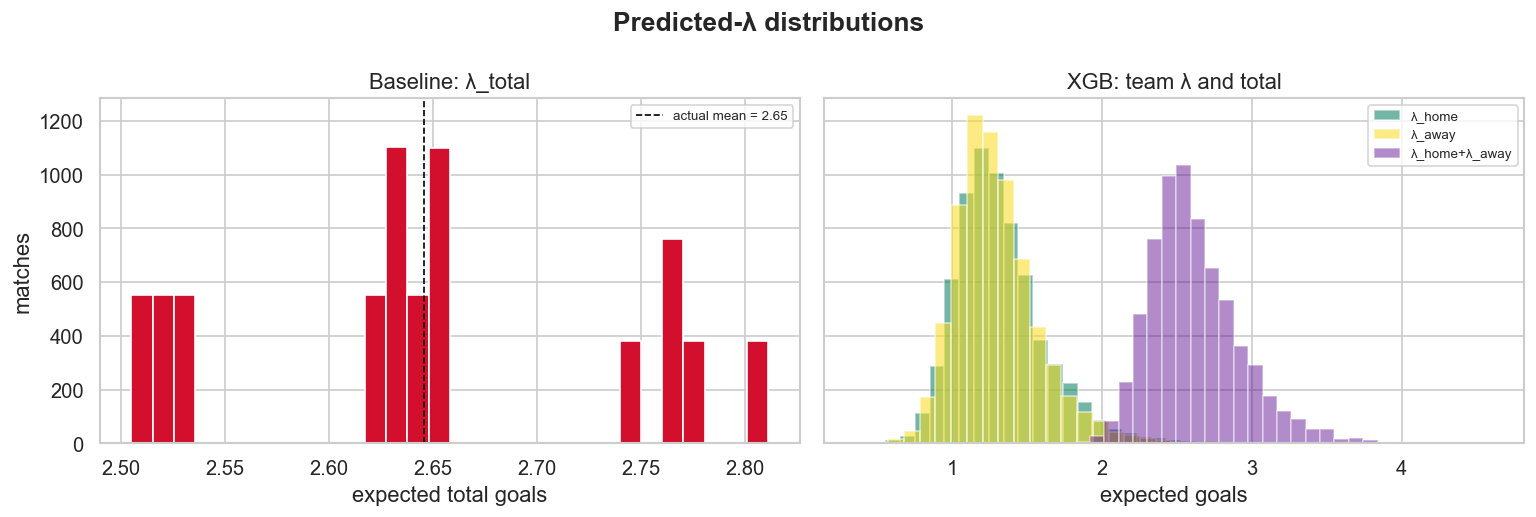

In [24]:
# Diagnostic 1 — predicted-lambda distributions.
MODEL_COLOUR = {'Baseline': COLOURS[3], 'XGB': COLOURS[2]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)

gb = preds[preds['model'] == 'Baseline']
axes[0].hist(gb['expected'], bins=30, color=MODEL_COLOUR['Baseline'], edgecolor='white')
axes[0].axvline(gb['total_goals'].mean(), color='black', ls='--', lw=1,
                label=f'actual mean = {gb["total_goals"].mean():.2f}')
axes[0].set_title('Baseline: λ_total'); axes[0].set_xlabel('expected total goals'); axes[0].legend(fontsize=8)

gx = preds[preds['model'] == 'XGB']
axes[1].hist(gx['lambda_home'], bins=30, alpha=0.55, color=COLOURS[0], label='λ_home', edgecolor='white')
axes[1].hist(gx['lambda_away'], bins=30, alpha=0.55, color=COLOURS[1], label='λ_away', edgecolor='white')
axes[1].hist(gx['expected'],    bins=30, alpha=0.45, color=COLOURS[2], label='λ_home+λ_away', edgecolor='white')
axes[1].set_title('XGB: team λ and total'); axes[1].set_xlabel('expected goals'); axes[1].legend(fontsize=8)

axes[0].set_ylabel('matches')
fig.suptitle('Predicted-λ distributions', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PATH / 'diag_lambda_distributions.png', bbox_inches='tight')
plt.show()

In [25]:
# Programmatic verdict — reads the master table so the prose can never drift from the numbers.
B = master.loc['Baseline']; X = master.loc['XGB']
d = B['logloss_mean'] - X['logloss_mean']
if abs(d) < 1e-4:
    verdict = f'Baseline and XGB are effectively tied on log loss (Δ = {d:+.4f}).'
else:
    better, mag = ('XGB', d) if d > 0 else ('Baseline', -d)
    verdict = f'{better} wins on log loss by {mag:.4f}.'

print('Total-goals log loss (mean ± std across folds):')
print(f'  Baseline: {B["logloss_mean"]:.4f} ± {B["logloss_std"]:.4f}')
print(f'  XGB     : {X["logloss_mean"]:.4f} ± {X["logloss_std"]:.4f}')
print(verdict)
print(f'\nMean rank (lower = better): Baseline={B["mean_rank"]:.3f}, XGB={X["mean_rank"]:.3f}')
print(f'Top-1 accuracy: Baseline={B["top1_%"]:.1f}%, XGB={X["top1_%"]:.1f}%')
print('Only XGB yields per-team λ -> scoreline matrix (BTTS / over-under / correct-score).')

Total-goals log loss (mean ± std across folds):
  Baseline: 1.8489 ± 0.0141
  XGB     : 1.8484 ± 0.0058
XGB wins on log loss by 0.0006.

Mean rank (lower = better): Baseline=3.012, XGB=3.010
Top-1 accuracy: Baseline=25.0%, XGB=25.1%
Only XGB yields per-team λ -> scoreline matrix (BTTS / over-under / correct-score).


## 16. Save

In [26]:
# Run manifest — full provenance so the next notebook and any audit can reproduce this run.
run_config = {
    'default_L':           DEFAULT_L,
    'default_ALPHA':       DEFAULT_ALPHA,
    'xgb_base_params':     XGB_BASE_PARAMS,
    'selected_features':   EVAL_FEATS,
    'full_feature_list':   TEAM_GOALS_FEATS,
    'n_features_selected': len(EVAL_FEATS),
    'n_features_full':     len(TEAM_GOALS_FEATS),
    'selected_features_path': str(OUT_PATH / 'selected_features.json'),
    'tuning_start_path':      str(OUT_PATH / 'tuning_start.json'),
    'test_season_cutoff':  TEST_SEASON,
    'timestamp':           datetime.datetime.now().isoformat(timespec='seconds'),
}
with open(OUT_PATH / 'run_config.json', 'w') as f:
    json.dump(run_config, f, indent=2)

print('Artifacts in', OUT_PATH.resolve())
for p in ['df_features_wide.csv', 'df_features_long.csv', 'model_comparison.csv',
          'tuning_start.json',
          'shap_summary.png', 'shap_importance.csv',
          'feature_group_search_pass1_results.csv', 'feature_group_search_pass2_results.csv',
          'feature_subset_search_results.csv',
          'selected_features_provisional.json', 'selected_features.json', 'run_config.json',
          'diag_lambda_distributions.png', 'diag_expected_calibration.png',
          'diag_probability_calibration.png', 'diag_probability_rank.png']:
    print(f'  {"OK " if (OUT_PATH / p).exists() else "-- "}{p}')

Artifacts in /Users/patrickknott/Desktop/CV/Quantitative Analysis - Task/Goal_Model/Outputs/Features
  OK df_features_wide.csv
  OK df_features_long.csv
  OK model_comparison.csv
  OK tuning_start.json
  OK shap_summary.png
  OK shap_importance.csv
  OK feature_group_search_pass1_results.csv
  OK feature_group_search_pass2_results.csv
  OK feature_subset_search_results.csv
  OK selected_features_provisional.json
  OK selected_features.json
  OK run_config.json
  OK diag_lambda_distributions.png
  -- diag_expected_calibration.png
  -- diag_probability_calibration.png
  -- diag_probability_rank.png
